In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminder_with_codes.csv"
df = pd.read_csv(url)
print(df)
print("Готово ✅")
print("Размер датасета:", df.shape)

          country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0     Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1     Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2     Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3     Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4     Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   
...           ...       ...   ...      ...       ...         ...       ...   
1699     Zimbabwe    Africa  1987   62.351   9216418  706.157306       ZWE   
1700     Zimbabwe    Africa  1992   60.377  10704340  693.420786       ZWE   
1701     Zimbabwe    Africa  1997   46.809  11404948  792.449960       ZWE   
1702     Zimbabwe    Africa  2002   39.989  11926563  672.038623       ZWE   
1703     Zimbabwe    Africa  2007   43.487  12311143  469.709298       ZWE   

      iso_num  
0           4  
1           4  
2           4  

In [2]:
# Таблица 1 — основная информация о странах
table_countries = df[['country', 'continent', 'year', 'pop']].copy()

# Таблица 2 — экономические показатели
table_economy = df[['country', 'year', 'gdpPercap', 'lifeExp']].copy()

print("Таблица 1 — страны:")
print(table_countries.shape)
print("\nТаблица 2 — экономика:")
print(table_economy.shape)

Таблица 1 — страны:
(1704, 4)

Таблица 2 — экономика:
(1704, 4)


In [3]:
# Объединяем две таблицы по country и year
df_merged = table_countries.merge(table_economy, 
                                   on=['country', 'year'])

print("Результат merge:")
print(df_merged.shape)
df_merged.head()

Результат merge:
(1704, 6)


,country,continent,year,pop,gdpPercap,lifeExp
0,Afghanistan,Asia,1952,8425333,779.445314,28.801
1,Afghanistan,Asia,1957,9240934,820.853030,30.332
2,Afghanistan,Asia,1962,10267083,853.100710,31.997
3,Afghanistan,Asia,1967,11537966,836.197138,34.020
4,Afghanistan,Asia,1972,13079460,739.981106,36.088


In [3]:
# Таблица А — только несколько стран
table_a = df[df['country'].isin(['Norway', 'Germany', 'Japan'])][['country', 'year', 'pop']]

# Таблица Б — другой набор стран
table_b = df[df['country'].isin(['Norway', 'Germany', 'Brazil'])][['country', 'year', 'gdpPercap']]

# Inner merge — только общие страны
inner = table_a.merge(table_b, on=['country', 'year'], how='inner')
print("Inner — только общие страны:")
print(inner['country'].unique())

Inner — только общие страны:
['Germany' 'Norway']


In [4]:
left = table_a.merge(table_b, on=['country', 'year'], how='left')
print("Left — все страны из левой таблицы:")
print(left['country'].unique())
print("\nЕсть ли пропуски?")
print(left.isnull().sum())

Left — все страны из левой таблицы:
['Germany' 'Japan' 'Norway']

Есть ли пропуски?
country       0
year          0
pop           0
gdpPercap    12
dtype: int64


In [10]:
print(df[df['country'] == 'Japan'])

    country continent  year  lifeExp        pop     gdpPercap iso_alpha  \
792   Japan      Asia  1952   63.030   86459025   3216.956347       JPN   
793   Japan      Asia  1957   65.500   91563009   4317.694365       JPN   
794   Japan      Asia  1962   68.730   95831757   6576.649461       JPN   
795   Japan      Asia  1967   71.430  100825279   9847.788607       JPN   
796   Japan      Asia  1972   73.420  107188273  14778.786360       JPN   
797   Japan      Asia  1977   75.380  113872473  16610.377010       JPN   
798   Japan      Asia  1982   77.110  118454974  19384.105710       JPN   
799   Japan      Asia  1987   78.670  122091325  22375.941890       JPN   
800   Japan      Asia  1992   79.360  124329269  26824.895110       JPN   
801   Japan      Asia  1997   80.690  125956499  28816.584990       JPN   
802   Japan      Asia  2002   82.000  127065841  28604.591900       JPN   
803   Japan      Asia  2007   82.603  127467972  31656.068060       JPN   

     iso_num  
792      

In [11]:
pivot = df.pivot_table(
    values='gdpPercap',      # что считаем
    index='year',            # строки
    columns='continent',     # колонки
    aggfunc='mean'           # как считаем
)

pivot.round(0)

continent,Africa,Americas,Asia,Europe,Oceania
year,,,,,
1952,1253.0,4079.0,5195.0,5661.0,10298.0
1957,1385.0,4616.0,5788.0,6963.0,11599.0
1962,1598.0,4902.0,5729.0,8365.0,12696.0
1967,2050.0,5668.0,5971.0,10144.0,14495.0
1972,2340.0,6491.0,8187.0,12480.0,16417.0
1977,2586.0,7352.0,7791.0,14284.0,17284.0
1982,2482.0,7507.0,7434.0,15618.0,18555.0
1987,2283.0,7793.0,7608.0,17214.0,20448.0
1992,2282.0,8045.0,8640.0,17062.0,20894.0


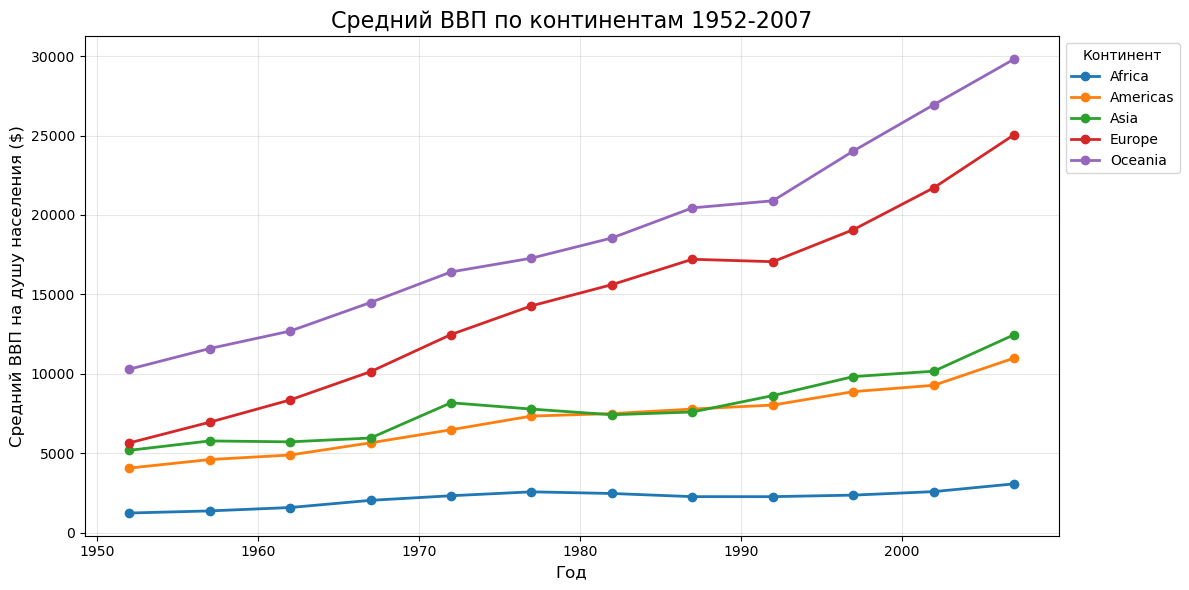

In [12]:
import matplotlib.pyplot as plt

pivot.plot(figsize=(12, 6), 
           marker='o',
           linewidth=2)

plt.title('Средний ВВП по континентам 1952-2007', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Средний ВВП на душу населения ($)', fontsize=12)
plt.legend(title='Континент', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
summary = df_2007 = df[df['year'] == 2007]

result = summary.groupby('continent').agg(
    средний_ВВП=('gdpPercap', 'mean'),
    макс_ВВП=('gdpPercap', 'max'),
    мин_жизнь=('lifeExp', 'min'),
    макс_жизнь=('lifeExp', 'max'),
    кол_стран=('country', 'count')
).round(1)

result

,средний_ВВП,макс_ВВП,мин_жизнь,макс_жизнь,кол_стран
continent,,,,,
Africa,3089.0,13206.5,39.6,76.4,52
Americas,11003.0,42951.7,60.9,80.7,25
Asia,12473.0,47307.0,43.8,82.6,33
Europe,25054.5,49357.2,71.8,81.8,30
Oceania,29810.2,34435.4,80.2,81.2,2


In [18]:
result2 = df[df['year'] == 2007].groupby('continent').agg(
    средний_ВВП=('gdpPercap', 'mean'),
    макс_ВВП=('gdpPercap', 'max'),
    страна_макс_ВВП=('gdpPercap', 'idxmax'),
    мин_жизнь=('lifeExp', 'min'),
    страна_мин_жизнь=('lifeExp', 'idxmin'),
    макс_жизнь=('lifeExp', 'max'),
    страна_макс_жизнь=('lifeExp', 'idxmax'),
    кол_стран=('country', 'count')
).round(1)

result2

,средний_ВВП,макс_ВВП,страна_макс_ВВП,мин_жизнь,страна_мин_жизнь,макс_жизнь,страна_макс_жизнь,кол_стран
continent,,,,,,,,
Africa,3089.0,13206.5,551,39.6,1463,76.4,1271,52
Americas,11003.0,42951.7,1619,60.9,647,80.7,251,25
Asia,12473.0,47307.0,863,43.8,11,82.6,803,33
Europe,25054.5,49357.2,1151,71.8,1583,81.8,695,30
Oceania,29810.2,34435.4,71,80.2,1103,81.2,71,2


In [19]:
df_2007 = df[df['year'] == 2007].reset_index(drop=True)

# Функция которая находит страну по максимуму
def get_country_max(x):
    return df_2007.loc[x.idxmax(), 'country']

def get_country_min(x):
    return df_2007.loc[x.idxmin(), 'country']

result3 = df_2007.groupby('continent').agg(
    макс_ВВП=('gdpPercap', 'max'),
    страна_макс_ВВП=('gdpPercap', get_country_max),
    мин_жизнь=('lifeExp', 'min'),
    страна_мин_жизнь=('lifeExp', get_country_min),
    макс_жизнь=('lifeExp', 'max'),
    страна_макс_жизнь=('lifeExp', get_country_max),
).round(1)

result3

,макс_ВВП,страна_макс_ВВП,мин_жизнь,страна_мин_жизнь,макс_жизнь,страна_макс_жизнь
continent,,,,,,
Africa,13206.5,Gabon,39.6,Swaziland,76.4,Reunion
Americas,42951.7,United States,60.9,Haiti,80.7,Canada
Asia,47307.0,Kuwait,43.8,Afghanistan,82.6,Japan
Europe,49357.2,Norway,71.8,Turkey,81.8,Iceland
Oceania,34435.4,Australia,80.2,New Zealand,81.2,Australia


In [24]:
dd = df[df['year'].isin([1952, 1972, 1992, 2007])]
pivot = dd.pivot_table(
    values='lifeExp',
    index='continent',
    columns='year',
    aggfunc='mean'
).round(1)

# Добавляем процент изменения
pivot['изменение_%'] = ((pivot[2007] - pivot[1952]) / pivot[1952] * 100).round(1)

# Сортируем по изменению
pivot.sort_values('изменение_%', ascending=False)

year,1952,1972,1992,2007,изменение_%
continent,,,,,
Asia,46.3,57.3,66.5,70.7,52.7
Africa,39.1,47.5,53.6,54.8,40.2
Americas,53.3,62.4,69.6,73.6,38.1
Europe,64.4,70.8,74.4,77.6,20.5
Oceania,69.3,71.9,76.9,80.7,16.5


In [25]:
pivot.to_csv('lifeexp_pivot.csv')
print("Сохранено ✅")

Сохранено ✅
